# Evaluation

The two axes and the style layer are built; this notebook evaluates them. It asks four questions in turn: whether the two axes measure distinct things (orthogonality), whether the public profile composite behaves as one coherent signal (internal coherence), how the two axes look when placed against each other (visualisation), and whether the competitive axis agrees with an independent ranking of the same fighters (Fight Matrix convergent validity).

Inputs are the frozen axis outputs from the earlier notebooks. Nothing here rebuilds a score; the axes are read and assessed as they stand.

In [ ]:
# BLOCK 1: imports and data location

from pathlib import Path

# data location (portable across Drive and a local repo checkout)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # not in Colab

DRIVE_DIR = Path('/content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/'
                 'Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs')
OUTPUT_DIR = DRIVE_DIR if DRIVE_DIR.exists() else Path('./data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using data

Mounted at /content/drive


In [ ]:
# BLOCK 2: Library setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import zscore
import requests
import time
import unicodedata
from datetime import datetime
from bs4 import BeautifulSoup
from io import StringIO

## Section 1: Are the two axes distinct?

The framework rests on the claim that competitive standing and public profile are related but not the same, so a fighter can rank high on one and low on the other. This block measures the rank correlation between the two axes across the active universe, and then on the more reliable subsets, to test whether they are distinct enough to justify keeping them apart.

In [ ]:
# BLOCK 3: load axes and headline correlation

glicko = pd.read_parquet(OUTPUT_DIR / 'glicko_current_continuous.parquet')
profile = pd.read_parquet(OUTPUT_DIR / 'public_profile_axis.parquet')

# the framework maps the active universe only
df = profile.merge(glicko[['FIGHTER', 'RATING', 'RD', 'TIER']], on='FIGHTER', how='inner')
print(f'fighters on both axes: {len(df)}')

# the axis rests on two sources (Wikipedia, GDELT)
def report_rho(label, sub):
    rho, p = spearmanr(sub['RATING'], sub['public_profile'])
    print(f'  {label:22} n={len(sub):3}  rho={rho:.3f}  p={p:.1e}')

print('Spearman (competitive vs public profile):')
report_rho('full universe', df)
report_rho('multi-source only', df[df['profile_reliability'] == 'multi_source'])
report_rho('Established tier', df[df['TIER'] == 'Established'])

# percentile-gap divergence: rank each axis and take the difference
df['comp_pct'] = df['RATING'].rank(pct=True) * 100
df['prof_pct'] = df['public_profile'].rank(pct=True) * 100
df['divergence'] = df['comp_pct'] - df['prof_pct']

# named exemplars come from the Established tier and multi-source profiles only
named = df[(df['TIER'] == 'Established') & (df['profile_reliability'] == 'multi_source')]
cols = ['FIGHTER', 'RATING', 'comp_pct', 'prof_pct', 'divergence']

print('\nHIGH competitive / LOW profile (largest positive divergence):')
print(named.nlargest(10, 'divergence')[cols].round(1).to_string(index=False))
print('\nHIGH profile / LOW competitive (largest negative divergence):')
print(named.nsmallest(10, 'divergence')[cols].round(1).to_string(index=False))

fighters on both axes: 791
Spearman (competitive vs public profile):
  full universe          n=791  rho=0.580  p=2.8e-72
  multi-source only      n=491  rho=0.715  p=4.1e-78
  Established tier       n=112  rho=0.750  p=1.8e-21

HIGH competitive / LOW profile (largest positive divergence):
             FIGHTER  RATING  comp_pct  prof_pct  divergence
            Rob Font  1743.5      77.2      25.8        51.5
Santiago Ponzinibbio  1733.3      75.5      29.1        46.4
        Ion Cutelaba  1610.9      51.2       6.3        44.9
          King Green  1772.9      82.6      42.1        40.5
          Drew Dober  1698.2      68.9      30.6        38.3
   Jonathan Martinez  1725.7      74.2      37.2        37.0
        Leon Edwards  1901.5      94.9      66.9        28.1
         Song Yadong  1877.7      92.7      65.9        26.8
    Marina Rodriguez  1639.6      57.8      32.0        25.8
          Niko Price  1564.3      41.0      19.7        21.2

HIGH profile / LOW competitive (large

### Orthogonality findings

The two axes are correlated but far from identical: the rank correlation is 0.580 across the active universe, 0.715 on the multi-source subset, and 0.750 among Established fighters. A relationship this strong confirms the axes are not measuring unrelated things, while a correlation well short of unity, even at the most reliable, leaves substantial room for a fighter to stand high on one axis and low on the other. That the correlation strengthens as rating reliability increases, rather than weakening, indicates the association is real structure rather than an artefact of noisy provisional ratings. The divergence table above lists the fighters furthest off the diagonal in each direction; the visualisation section examines what that separation looks like and why a single merged score would misrank them.

## Section 2: Internal coherence of the public profile composite

The public profile score averages three standardised attention signals into one composite. This block tests whether those signals behave as a single underlying dimension, which is the condition under which averaging them into one score is appropriate, and whether the equal weighting holds. The proposal committed to reweighting the composite only if the check revealed more than one dimension, so the result either supports the equal weighting as specified or triggers a revision.
Coherence is assessed on the fighters carrying all three signals, through the inter-signal correlations, the eigenvalues of their correlation matrix, the loadings on the first component, and Cronbach's alpha. A formal multi-factor model is not identifiable on three indicators, so the check is reported as one-factor coherence with an internal-consistency coefficient rather than a full exploratory factor analysis.

In [ ]:
# BLOCK 4: internal coherence of the public profile composite

# do the three attention signals cohere as one dimension, and is equal weighting defensible?
# reload the axis and rebuild the standardised signals as the composite uses them (log1p then
# z-score); the parquet stores raw components, not the z-scores.
prof = pd.read_parquet(OUTPUT_DIR / 'public_profile_axis.parquet')
sig = ['pv_baseline', 'pv_activation', 'gdelt_volume']
with np.errstate(invalid='ignore'):
    Z = pd.DataFrame({s: (np.log1p(prof[s]) - np.log1p(prof[s]).mean()) / np.log1p(prof[s]).std()
                      for s in sig})

# coherence is assessed on fighters carrying all three signals, so every pair is present
complete = Z.dropna()
print(f'complete-case fighters (all three signals): {len(complete)} of {len(prof)}')

# inter-signal correlation: baseline and activation are two windows on one source and correlate
# strongly; GDELT is the second source
R = complete.corr()
print('\ninter-signal correlation:')
print(R.round(3).to_string())

# one dimension or several? eigenvalues of the correlation matrix, and variance on the first
ev = np.sort(np.linalg.eigvalsh(R.values))[::-1]
print(f'\neigenvalues: {np.round(ev, 3)}')
print(f'components with eigenvalue > 1 (Kaiser): {(ev > 1).sum()}')
print(f'variance explained by the first component: {ev[0] / ev.sum():.3f}')

# loadings on the first component (eigenvector scaled by sqrt of its eigenvalue)
w, v = np.linalg.eigh(R.values)
first = v[:, np.argmax(w)] * np.sqrt(w.max())
if first.mean() < 0:
    first = -first
print('\nfirst-component loadings:')
for s, l in zip(R.columns, first):
    print(f'  {s:14} {l:.3f}')

# Cronbach's alpha (standardised), the internal-consistency measure named in the proposal,
# from the mean inter-signal correlation
k = len(sig)
r_bar = R.values[np.triu_indices(k, 1)].mean()
alpha = k * r_bar / (1 + (k - 1) * r_bar)
print(f'\nmean inter-signal correlation: {r_bar:.3f}')
print(f"Cronbach's alpha (standardised, k={k}): {alpha:.3f}")

complete-case fighters (all three signals): 477 of 791

inter-signal correlation:
               pv_baseline  pv_activation  gdelt_volume
pv_baseline          1.000          0.875         0.583
pv_activation        0.875          1.000         0.471
gdelt_volume         0.583          0.471         1.000

eigenvalues: [2.302 0.584 0.114]
components with eigenvalue > 1 (Kaiser): 1
variance explained by the first component: 0.767

first-component loadings:
  pv_baseline    0.950
  pv_activation  0.911
  gdelt_volume   0.755

mean inter-signal correlation: 0.643
Cronbach's alpha (standardised, k=3): 0.844


### Public profile coherence findings

The three signals cohere as one dimension. The correlation matrix has a single eigenvalue above one, the first component accounts for 77% of the variance, and all three signals load on it (0.95, 0.91, 0.76); Cronbach's alpha is 0.844, indicating good internal consistency. The composite is therefore unidimensional, and the equal weighting stands under the proposal's own criterion, which was to reweight only if multiple dimensions emerged.
Baseline and activation correlate at 0.875, higher than either correlates with news volume, because they are two time-windows on the same source rather than independent signals. Pageviews consequently carry more of the composite than a count of three signals would suggest. This is disclosed rather than corrected: the distinction between durable baseline attention and fight-driven activation is a deliberate part of the axis design, so the two windows are retained as separate inputs and their shared source is noted.

## Section 3: Visualising the two axes

The correlation coefficient states how much the axes share; the scatter shows where they diverge. Each fighter is placed by competitive rating against public-profile score, so the framework's claim is legible directly: a diagonal band would mean the axes are redundant, while a populated spread, in particular the off-diagonal corners, shows fighters whom a single collapsed score would misrank. The corner exemplars are labelled because they are the evidence that the two axes measure distinct things.

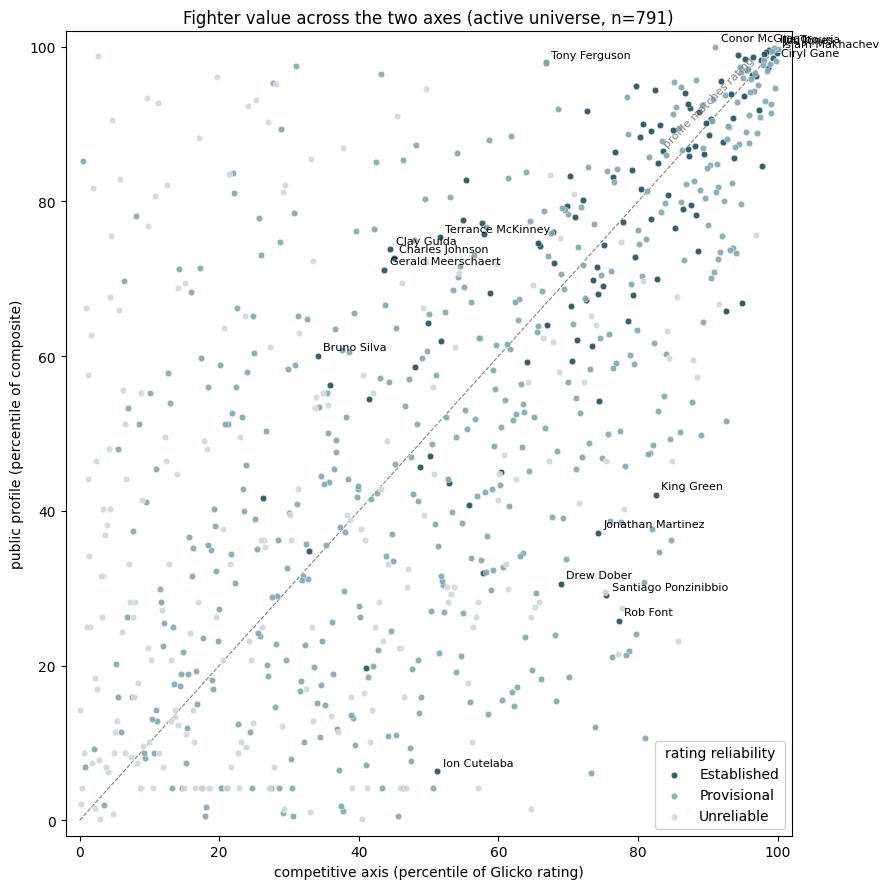

In [ ]:
# BLOCK 5: the two axes as percentiles

fig, ax = plt.subplots(figsize=(9, 9))

# each fighter plotted by rank on the two axes
tier_colour = {'Established': '#1f4e5f', 'Provisional': '#7fa8b5', 'Unreliable': '#cfd8dc'}
for tier, c in tier_colour.items():
    sub = df[df['TIER'] == tier]
    ax.scatter(sub['comp_pct'], sub['prof_pct'], s=22, c=c, label=tier,
               edgecolors='white', linewidths=0.3, alpha=0.9)

# profile percentile equals competitive percentile
ax.plot([0, 100], [0, 100], color='grey', ls='--', lw=0.8, zorder=0)
ax.text(96, 99, 'profile matches rating', fontsize=8, color='grey',
        rotation=45, ha='right', va='top', rotation_mode='anchor')

# label the fighters furthest off the diagonal in each direction (reliable readings only)
tag = df[(df['TIER'] == 'Established') & (df['profile_reliability'] == 'multi_source')]
to_label = pd.concat([
    tag.nlargest(6, 'divergence'),      # high competitive, low profile
    tag.nsmallest(6, 'divergence'),     # high profile, low competitive
    df.nlargest(3, 'comp_pct'),
    df.nlargest(3, 'prof_pct'),
]).drop_duplicates('FIGHTER')

for _, r in to_label.iterrows():
    ax.annotate(r['FIGHTER'], (r['comp_pct'], r['prof_pct']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('competitive axis (percentile of Glicko rating)')
ax.set_ylabel('public profile (percentile of composite)')
ax.set_xlim(-2, 102); ax.set_ylim(-2, 102)
ax.set_title('Fighter value across the two axes (active universe, n=%d)' % len(df))
ax.legend(title='rating reliability', loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'orthogonality_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

The two axes are positively correlated across the active universe (Spearman 0.580, rising to 0.715 on the multi-source subset and 0.750 among Established tier ratings); they are related, not independent. Two features of that correlation bear on its interpretation. It is measured on a profile axis that shares no input with the competitive axis, the main-event signal having been removed from the composite, so it reflects covariation between competitive standing and public attention rather than an artefact of shared construction; and it rises, rather than weakens, as rating reliability increases, which points to real structure rather than rating noise. The scatter shows why a single collapsed score would nonetheless mislead: the distribution is a broad band rather than a diagonal, and the off diagonal corners are occupied by identifiable fighters. Ferguson and Guida carry high public profile against merely solid competitive ratings, while Rob Font and Santiago Ponzinibbio hold strong ratings with markedly lower profiles; the corner reaches as high as a recent titleholder, Leon Edwards, whose profile sits well below his competitive standing.

These fighters are ranked correctly on each axis and would be misplaced by any measure that merged the two. The framework's contribution is therefore the separation of two distinct but correlated dimensions of fighter value, evidenced by the populated corners, rather than a claim that ability and profile are independent.

## Section 4: Fight Matrix rank comparison

In [ ]:
# BLOCK 6: Fight Matrix fetch helper and config

# fight matrix is plain apache; descriptive UA and spaced requests
USER_AGENT = "UFC-Value-Mapper/0.1 (MSc academic project; contact via GitHub th1555)"
HEADERS = {"User-Agent": USER_AGENT}
REQUEST_DELAY = 2
BASE = "https://www.fightmatrix.com"


def fetch(url, headers=HEADERS, timeout=15):
    # returns (text, status), or (None, None) on request failure
    try:
        r = requests.get(url, headers=headers, timeout=timeout)
        print(f"  GET {url}")
        print(f"    status: {r.status_code}, length: {len(r.text):,} chars")
        return r.text, r.status_code
    except Exception as e:
        print(f"  GET {url} FAILED: {type(e).__name__}: {e}")
        return None, None

In [ ]:
# BLOCK 7: division dropdowns and list the issues bracketing the freeze

FREEZE = datetime(2026, 7, 11)

# any valid historical page carries the full issue and division dropdowns
seed_url = f"{BASE}/historical-mma-rankings/ranking-snapshots/?Issue=1005&Division=3"
hist_html, hist_status = fetch(seed_url)
time.sleep(REQUEST_DELAY)

issue_lookup = {}       # {issue_id: date_string}
division_lookup = {}    # {division_id: division_name}

if hist_html and hist_status == 200:
    soup = BeautifulSoup(hist_html, 'html.parser')
    for sel in soup.find_all('select'):
        name_attr = (sel.get('name') or '').lower()
        opt_map = {}
        for opt in sel.find_all('option'):
            val = opt.get('value', '').strip()
            txt = opt.get_text(strip=True)
            if val:
                opt_map[val] = txt
        if 'issue' in name_attr:
            issue_lookup = opt_map
        elif 'division' in name_attr:
            division_lookup = opt_map
else:
    print("  could not fetch seed page; dropdowns not harvested")

print(f"\nissues harvested: {len(issue_lookup)}")
print(f"divisions harvested: {len(division_lookup)}")

# parse issue dates as MM/DD/YYYY so the freeze can be bracketed; skip anything unparseable
issues_dated = []
for iid, dstr in issue_lookup.items():
    try:
        d = datetime.strptime(dstr, '%m/%d/%Y')
        issues_dated.append((iid, dstr, d))
    except ValueError:
        continue
issues_dated.sort(key=lambda x: x[2])

# the issues within ~75 days either side of the freeze, with signed day offset
print(f"\nissues around the freeze ({FREEZE:%d/%m/%Y}):")
for iid, dstr, d in issues_dated:
    if abs((d - FREEZE).days) <= 75:
        delta = (d - FREEZE).days
        side = 'pre ' if delta < 0 else 'post'
        print(f"  issue {iid}: {dstr}  ({side} freeze, {delta:+d} days)")

# the 14 scored divisions; exclude pound-for-pound (-1, -2) and dominance lists (11, 17)
EXCLUDE_DIV = {'-1', '-2', '11', '17'}
print(f"\nscored divisions:")
for vid, vname in division_lookup.items():
    if vid not in EXCLUDE_DIV:
        print(f"  {vid}: {vname}")

  GET https://www.fightmatrix.com/historical-mma-rankings/ranking-snapshots/?Issue=1005&Division=3
    status: 200, length: 124,648 chars

issues harvested: 224
divisions harvested: 18

issues around the freeze (11/07/2026):
  issue 1022: 05/03/2026  (pre  freeze, -69 days)
  issue 1027: 06/07/2026  (pre  freeze, -34 days)
  issue 1031: 07/05/2026  (pre  freeze, -6 days)

scored divisions:
  1: Heavyweight
  2: LightHeavyweight
  3: Middleweight
  4: Welterweight
  5: Lightweight
  6: Featherweight
  7: Bantamweight
  8: Flyweight
  9: Strawweight
  16: Women - Featherweight+
  15: Women - Bantamweight
  14: Women - Flyweight
  13: Women - Strawweight
  12: Women - Atomweight


In [ ]:
# BLOCK 8: pull the twelve UFC division snapshots (parse only, no save)

ISSUE_ID = '1031'
ISSUE_DATE = '07/05/2026'   # mm/dd/yyyy, 6 days before the 11 jul freeze

# ufc divisions only
TARGET_DIVISIONS = {
    '1': 'Heavyweight', '2': 'LightHeavyweight', '3': 'Middleweight', '4': 'Welterweight',
    '5': 'Lightweight', '6': 'Featherweight', '7': 'Bantamweight', '8': 'Flyweight',
    '13': 'Women - Strawweight', '14': 'Women - Flyweight',
    '15': 'Women - Bantamweight', '16': 'Women - Featherweight+',
}

snapshot_path = OUTPUT_DIR / f'fightmatrix_ranks_{ISSUE_ID}.parquet'


def snapshot_url(issue_id, div_id, org_filter=False):
    url = f"{BASE}/historical-mma-rankings/ranking-snapshots/?Issue={issue_id}&Division={div_id}"
    return url + "&OrgFilter=UFC" if org_filter else url


def parse_snapshot(html):
    if not html:
        return None
    try:
        tables = pd.read_html(StringIO(html))
    except ValueError:
        return None  # read_html raises when it finds no tables at all
    # ranking table is the 4-col one with most rows; fall back to longest overall
    four_col = [t for t in tables if t.shape[1] == 4]
    tbl = max(four_col, key=len) if four_col else (max(tables, key=len) if tables else None)
    if tbl is None:
        return None
    # coerce rank/points to numeric so the leaked header row becomes NaN and drops
    out = pd.DataFrame({
        'fm_rank': pd.to_numeric(tbl.iloc[:, 0], errors='coerce'),
        'fm_name': tbl.iloc[:, 2].astype(str).str.strip(),
        'points':  pd.to_numeric(tbl.iloc[:, 3], errors='coerce'),
    }).dropna(subset=['fm_rank']).reset_index(drop=True)
    out['fm_rank'] = out['fm_rank'].astype(int)
    return out


if snapshot_path.exists():
    # cached
    fm_ranks = pd.read_parquet(snapshot_path)
    print(f'loaded cached snapshot: {snapshot_path.name}  ({len(fm_ranks)} rows)')
else:
    # one-off: does OrgFilter=UFC change a historical snapshot?
    p_html, _ = fetch(snapshot_url(ISSUE_ID, '5'));               time.sleep(REQUEST_DELAY)
    f_html, _ = fetch(snapshot_url(ISSUE_ID, '5', org_filter=True)); time.sleep(REQUEST_DELAY)
    p_names, f_names = parse_snapshot(p_html), parse_snapshot(f_html)
    if p_names is not None and f_names is not None:
        same = p_names['fm_name'].tolist() == f_names['fm_name'].tolist()
        print(f"\nOrgFilter probe (lightweight): "
              f"{'IGNORED, snapshots are all-organisation' if same else 'ACTIVE, filters to UFC'}"
              f"  (plain {len(p_names)} vs filtered {len(f_names)} names)\n")
    else:
        print("\nOrgFilter probe inconclusive: one of the two pages did not parse\n")

    # pull each target division plain
    frames = []
    for div_id, div_name in TARGET_DIVISIONS.items():
        html, status = fetch(snapshot_url(ISSUE_ID, div_id))
        time.sleep(REQUEST_DELAY)
        parsed = parse_snapshot(html)
        if parsed is None or parsed.empty:
            print(f"  division {div_id} ({div_name}): no table parsed")
            continue
        parsed.insert(0, 'division_name', div_name)
        parsed.insert(0, 'division_id', div_id)
        frames.append(parsed)
        print(f"  division {div_id} ({div_name}): {len(parsed)} ranked fighters")

    fm_ranks = pd.concat(frames, ignore_index=True)
    fm_ranks['issue_id'] = ISSUE_ID
    fm_ranks['issue_date'] = ISSUE_DATE

# summary
print(f"\ntotal rows: {len(fm_ranks)}")
print(f"divisions present: {fm_ranks['division_id'].nunique()} of {len(TARGET_DIVISIONS)}")
print("\nrows per division:")
print(fm_ranks.groupby(['division_id', 'division_name'], sort=False).size().to_string())
print("\nsample (lightweight top 5):")
print(fm_ranks[fm_ranks.division_id == '5'].head(5).to_string(index=False))

loaded cached snapshot: fightmatrix_ranks_1031.parquet  (285 rows)

total rows: 285
divisions present: 12 of 12

rows per division:
division_id  division_name         
1            Heavyweight               25
2            LightHeavyweight          25
3            Middleweight              25
4            Welterweight              25
5            Lightweight               25
6            Featherweight             25
7            Bantamweight              25
8            Flyweight                 25
13           Women - Strawweight       25
14           Women - Flyweight         25
15           Women - Bantamweight      25
16           Women - Featherweight+    10

sample (lightweight top 5):
division_id division_name  fm_rank          fm_name  points issue_id issue_date
          5   Lightweight        1   Justin Gaethje  2677.0     1031 07/05/2026
          5   Lightweight        2     Ilia Topuria  2193.0     1031 07/05/2026
          5   Lightweight        3 Charles Oliveira  2015.0

In [ ]:
# BLOCK 9: save the Fight Matrix snapshot artefact

# guarded so it writes once
if not snapshot_path.exists():
    fm_ranks.to_parquet(snapshot_path, index=False)
    print(f'saved: {snapshot_path.name}  ({len(fm_ranks)} rows)')
else:
    print(f'already cached, not overwriting: {snapshot_path.name}')

already cached, not overwriting: fightmatrix_ranks_1031.parquet


In [ ]:
# BLOCK 10: resolve the Fight Matrix names against the rated roster

def normalise_name(name):
    # lowercase, strip diacritics, drop apostrophes and periods, hyphens to spaces
    s = unicodedata.normalize('NFKD', str(name))
    s = ''.join(c for c in s if not unicodedata.combining(c))     # strip accents
    s = s.lower().replace("'", "").replace("\u2019", "").replace(".", "")
    s = s.replace("-", " ")
    return ' '.join(s.split())

def direct_match(canonical, target_names):
    canon_norm = normalise_name(canonical)
    for t in target_names:
        if normalise_name(t) == canon_norm:
            return t
    return None

def token_sort_match(canonical, target_names):
    # sort tokens so name-order flips match
    canon_sorted = ' '.join(sorted(normalise_name(canonical).split()))
    for t in target_names:
        if ' '.join(sorted(normalise_name(t).split())) == canon_sorted:
            return t
    return None

def resolve_name(canonical, target_names):
    # no alias layer; manual overrides handled after the loop
    r = direct_match(canonical, target_names)
    if r:
        return r, 'direct'
    r = token_sort_match(canonical, target_names)
    if r:
        return r, 'token_sort'
    return None, 'unmatched'


# match target is names carrying a Glicko RATING
rated_names = glicko['FIGHTER'].tolist()

records = []
for _, row in fm_ranks.iterrows():
    matched_name, method = resolve_name(row['fm_name'], rated_names)
    records.append({
        'division_id': row['division_id'], 'division_name': row['division_name'],
        'fm_rank': row['fm_rank'], 'fm_name': row['fm_name'],
        'fighter': matched_name, 'method': method,
    })
fm_matched = pd.DataFrame(records)

# manual overrides
FM_ALIAS = {
    'Ian Garry': 'Ian Machado Garry',
    'Renato Carneiro': 'Renato Moicano',
    'Khalil Rountree': 'Khalil Rountree Jr.',
    'Benoit St. Denis': 'Benoit Saint Denis',
    'Sharabutdin Magomedov': 'Shara Magomedov',
    'Lupita Godinez': 'Loopy Godinez',
    'Beatriz Mesquita': 'Bia Mesquita',
    'Alexander Romanov': 'Alexandr Romanov',
}
# every alias target must exist in the rated roster
_bad = {fm: tgt for fm, tgt in FM_ALIAS.items() if tgt not in set(rated_names)}
if _bad:
    print("WARNING: alias targets not in rated roster:")
    for fm, tgt in _bad.items():
        print(f"  {fm!r} -> {tgt!r}")
_alias = fm_matched['fighter'].isna() & fm_matched['fm_name'].isin(FM_ALIAS)
fm_matched.loc[_alias, 'fighter'] = fm_matched.loc[_alias, 'fm_name'].map(FM_ALIAS)
fm_matched.loc[_alias, 'method'] = 'alias'
print(f"aliases applied: {int(_alias.sum())} of {len(FM_ALIAS)}")

matched = fm_matched[fm_matched['fighter'].notna()]
unmatched = fm_matched[fm_matched['fighter'].isna()]

print(f"\nfm names: {len(fm_matched)}  matched: {len(matched)}  unmatched: {len(unmatched)}")
print("\nby method:")
print(matched['method'].value_counts().to_string())

print("\ntoken-sort matches (name-order flips caught):")
print(matched[matched.method == 'token_sort'][['fm_name', 'fighter']].to_string(index=False))

print("\nunmatched fm names by division:")
for div, grp in unmatched.groupby('division_name', sort=False):
    print(f"  {div}: {', '.join(grp['fm_name'].tolist())}")

aliases applied: 8 of 8

fm names: 285  matched: 214  unmatched: 71

by method:
method
direct        201
alias           8
token_sort      5

token-sort matches (name-order flips caught):
      fm_name       fighter
  Yadong Song   Song Yadong
  Weili Zhang   Zhang Weili
  Xiaonan Yan   Yan Xiaonan
Jingnan Xiong Xiong Jingnan
    Cong Wang     Wang Cong

unmatched fm names by division:
  Heavyweight: Vadim Nemkov, Denis Goltsov, Sergey Bilostenniy, Phil De Fries, Oleg Popov, Renan Ferreira, Anatoly Malykhin
  LightHeavyweight: Dovletdzhan Yagshimuradov, Valentin Moldavsky, Antonio Carlos Jr., Sullivan Cauley, Luke Trainer
  Middleweight: Costello Van Steenis, Johnny Eblen, Fabian Edwards, Magomedrasul Gasanov
  Welterweight: Ramazan Kuramagomedov, Thad Jean, Jason Jackson, Shamil Musaev
  Lightweight: Usman Nurmagomedov, Abdul-Aziz Abdulvakhabov, Paul Hughes, Gadzhi Rabadanov, Alexandr Shabliy, Alfie Davis, Archie Colgan, Daud Shaikhaev, Sidney Outlaw
  Featherweight: A.J. McKee, Rajab

In [ ]:
# BLOCK 11: attach Glicko rating and per-division n
comp = (matched
        .merge(glicko[['FIGHTER', 'RATING', 'RD', 'TIER']],
               left_on='fighter', right_on='FIGHTER', how='inner')
        .drop(columns='FIGHTER'))
print(f"comparison rows (ranked and rated): {len(comp)}")
print("\nper-division n:")
counts = (comp.groupby(['division_id', 'division_name'], sort=False)
              .agg(n=('fighter', 'size'),
                   n_established=('TIER', lambda s: (s == 'Established').sum()))
              .reset_index())
print(counts.to_string(index=False))

comparison rows (ranked and rated): 214

per-division n:
division_id          division_name  n  n_established
          1            Heavyweight 18              5
          2       LightHeavyweight 20              9
          3           Middleweight 21              8
          4           Welterweight 21              7
          5            Lightweight 16              8
          6          Featherweight 19              3
          7           Bantamweight 22              9
          8              Flyweight 18              3
         13    Women - Strawweight 22              7
         14      Women - Flyweight 18              2
         15   Women - Bantamweight 18              0
         16 Women - Featherweight+  1              0


In [ ]:
# BLOCK 12: per-division Spearman, Glicko order vs Fight Matrix rank

# put both sides on the same within-division ordinal scale (1 = best), so a
# positive coefficient means the two orderings agree
comp['glicko_rank'] = comp.groupby('division_id')['RATING'].rank(ascending=False)

MIN_N = 10  # a rank correlation below this is too unstable to report as a result

rows = []
for (div_id, div_name), g in comp.groupby(['division_id', 'division_name'], sort=False):
    if len(g) < MIN_N:
        rows.append({'division': div_name, 'n': len(g), 'rho': None, 'p': None})
        continue
    rho, p = spearmanr(g['glicko_rank'], g['fm_rank'])
    rows.append({'division': div_name, 'n': len(g), 'rho': round(rho, 3), 'p': round(p, 4)})

res = pd.DataFrame(rows)
print(res.to_string(index=False))

reported = res[res['rho'].notna()]
print(f"\ndivisions reported: {len(reported)} (Women - Featherweight+ dropped, n too small)")
print(f"median rho: {reported['rho'].median():.3f}   "
      f"range: {reported['rho'].min():.3f} to {reported['rho'].max():.3f}")

              division  n   rho      p
           Heavyweight 18 0.915 0.0000
      LightHeavyweight 20 0.647 0.0021
          Middleweight 21 0.853 0.0000
          Welterweight 21 0.878 0.0000
           Lightweight 16 0.826 0.0001
         Featherweight 19 0.867 0.0000
          Bantamweight 22 0.781 0.0000
             Flyweight 18 0.814 0.0000
   Women - Strawweight 22 0.822 0.0000
     Women - Flyweight 18 0.783 0.0001
  Women - Bantamweight 18 0.717 0.0008
Women - Featherweight+  1   NaN    NaN

divisions reported: 11 (Women - Featherweight+ dropped, n too small)
median rho: 0.822   range: 0.647 to 0.915


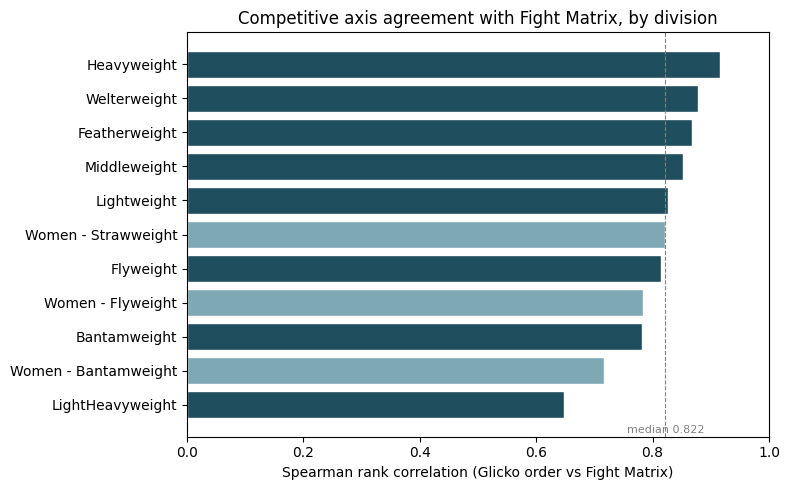

In [ ]:
# BLOCK 12b: per-division Spearman as a chart
fig, ax = plt.subplots(figsize=(8, 5))

# sort so the strongest agreement sits at the top of the horizontal bars
plot_df = reported.sort_values('rho', ascending=True)

# colour the women's divisions distinctly so the reader can separate the two groups
bar_colours = ['#7fa8b5' if d.startswith('Women') else '#1f4e5f'
               for d in plot_df['division']]

ax.barh(plot_df['division'], plot_df['rho'], color=bar_colours, edgecolor='white')

# mark the median so the headline figure is visible in the chart
med = reported['rho'].median()
ax.axvline(med, color='grey', ls='--', lw=0.8)
ax.text(med, -0.6, f'median {med:.3f}', fontsize=8, color='grey', ha='center', va='top')

ax.set_xlabel('Spearman rank correlation (Glicko order vs Fight Matrix)')
ax.set_xlim(0, 1)
ax.set_title('Competitive axis agreement with Fight Matrix, by division')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'division_spearman.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# BLOCK 13: pooled reliability robustness

# does the agreement holds after ratings are restricted to reliable ones
big = comp.groupby('division_id')['fighter'].transform('size') >= MIN_N
pool = comp[big].copy()

def pooled_rho(frame):
    rho, p = spearmanr(frame['glicko_rank'], frame['fm_rank'])
    return len(frame), round(rho, 3), p

n_all, rho_all, p_all = pooled_rho(pool)
est = pool[pool['TIER'] == 'Established']
n_est, rho_est, p_est = pooled_rho(est)

print(f"pooled full:        n={n_all}  rho={rho_all}")
print(f"pooled Established: n={n_est}  rho={rho_est}")
print("\n(within-division ranks pooled; p-values omitted as the pooled n overstates independence,")
print(" inferential weight rests on the per division significance)")

pooled full:        n=213  rho=0.814
pooled Established: n=61  rho=0.905

(within-division ranks pooled; p-values omitted as the pooled n overstates independence,
 inferential weight rests on the 11-of-11 per-division significance in 4g)


Across the eleven divisions with sufficient overlap, the competitive axis and the Fight Matrix rankings agree closely and consistently: per division Spearman coefficients span 0.647 to 0.915 with a median of 0.822, and all eleven are significant at p < 0.01. Agreement is not confined to a few well-covered divisions but holds across the roster, weakest at Light Heavyweight and strongest at Heavyweight. Women's Featherweight+ is excluded rather than reported, since only one of its ranked fighters falls inside the rated universe and a rank correlation cannot be computed from a single pair.

Restricting the pooled comparison to reliably rated fighters strengthens the agreement rather than merely preserving it, rising from 0.814 across all 213 within-division pairs to 0.905 across the 61 Established fighters; the disagreements in the full set therefore concentrate among provisional ratings, and the residual gap reflects rating uncertainty rather than a systematic difference in what the two systems measure. The same moderation appears in the orthogonality analysis, where the inter axis correlation also rose on the Established subset; provisional ratings attenuate every correlation the competitive axis enters, so the reliable figures are the less-attenuated estimates of the underlying relationships. The agreement is read as convergent validity rather than external proof: two rating systems built from the same fight results are expected to converge, so the close fit confirms that the competitive axis behaves like an established peer and is not broken, which is what this strand is designed to establish. One limitation remains, the six day gap between the 5 July snapshot and the 11 July freeze, under which the Fight Matrix snapshot does not yet reflect UFC 329.

In [ ]:
# BLOCK 14: public profile component diagnostic

# read the frozen public profile axis
prof = globals().get('profile', None)
if prof is None:
    prof = pd.read_parquet('public_profile_axis.parquet')

# the three equal weighted components (Trends and main event rate are not part of the composite)
comp_cols = ['pv_baseline', 'pv_activation', 'gdelt_volume']

# recompute the per-signal z-scores exactly as the composite does: log1p the counts, then z
z = prof.copy()
for c in comp_cols:
    z[c + '_z'] = zscore(np.log1p(z[c].fillna(0)))

# axis percentile (0-100), the legible version of the score
z['profile_pct'] = z['public_profile'].rank(pct=True).mul(100).round(0)

names = ['Sean O\'Malley', 'Merab Dvalishvili', 'Paddy Pimblett', 'Ilia Topuria', 'Conor McGregor']
cols = ['FIGHTER', 'public_profile', 'profile_pct',
        'pv_baseline_z', 'pv_activation_z', 'gdelt_volume_z']
view = z[z['FIGHTER'].isin(names)][cols].set_index('FIGHTER').round(2)
print('Per-signal contribution to the public profile score (z-scores):')
print(view.to_string())

# also show the raw component values so a mis-scale would be obvious
raw = prof[prof['FIGHTER'].isin(names)][['FIGHTER'] + comp_cols].set_index('FIGHTER')
print('\nRaw component values:')
print(raw.round(1).to_string())

                   public_profile  profile_pct  pv_baseline_z  pv_activation_z  gdelt_volume_z  main_event_rate_z
FIGHTER                                                                                                          
Ilia Topuria                 2.15        100.0           2.16              NaN            2.47               3.68
Merab Dvalishvili            1.49         97.0           1.75              NaN            1.83               1.50
Sean O'Malley                1.68         98.0           1.70              NaN            1.96               1.75
Paddy Pimblett               1.34         96.0           1.92              NaN            0.53               0.47
Conor McGregor               2.36        100.0           2.25              NaN            2.29               6.16

raw components:
                   pv_baseline  pv_activation  gdelt_volume  main_event_rate
FIGHTER                                                                     
Ilia Topuria            4693.5 

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
